In [1]:
# Arctic regions geospatial wrangling

In [7]:
import pandas as pd 
import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt
import os 

In [10]:
fp = os.path.join('arctic_communities.geojson')
df = gpd.read_file(fp)

In [87]:
# 2. Check geometry types
df.geom_type
df.geom_type.size

15

Create an if-else statement that:

prints “Multiple feature types:” followed by the unique geometry types (no repetition) in the geodataframe if not all the features are polygons, and

prints “All features are:” followed by the unique geometry type if all the features in the geodataframe have the same geometry type.


In [90]:
if df.geom_type.unique().size >1:  # Use ".size"
    print("Multiple feature types")
else: 
    print(f"all features are {df.geom_type.unique}")
    

    

if len(df.geom_type.unique())>1:  # Use "len()"
    print("Multiple feature types")
else: 
    print(f"all features are {df.geom_type.unique}")

Multiple feature types
Multiple feature types


Wrap up your code into a function named check_polygons that receives a single geodataframe as its parameter and prints out a message about the geometry types in the geodataframe.

In [23]:
def are_polygons(df):
    if len(df.geom_type.unique())>1: 
        print("Multiple feature types")
    else: 
        print(f"all features are {df.geom_type.unique}")

are_polygons(df)

Multiple feature types


# 3. Explode polygons

Overwrite the df geodataframe with the output from the explode method with the index_parts parameter set to False. Read the documentation for the method and use a markdown cell to write a brief explanation of what is being done.

Reset the index of df.

Use your check_polygons function to verify that df only has features of type polygon.


In [92]:
exploded = df.explode(column = 'geometry', index_parts = False).reset_index()
exploded

,index,admin,country,n_communities,geometry
0,0,United States of America,US,115,"POLYGON ((-132.74687 56.52568, -132.75762 56.5..."
1,0,United States of America,US,115,"POLYGON ((-132.77988 56.24727, -132.83096 56.2..."
2,0,United States of America,US,115,"POLYGON ((-134.31274 58.22891, -134.31987 58.2..."
3,0,United States of America,US,115,"POLYGON ((-145.11851 60.33711, -145.15049 60.3..."
4,0,United States of America,US,115,"POLYGON ((-144.56563 59.81841, -144.61357 59.8..."
...,...,...,...,...,...
476,13,Canada,CA,7,"POLYGON ((-109.16641 67.98237, -109.05391 67.9..."
477,13,Canada,CA,7,"POLYGON ((-108.09272 67.00518, -107.96646 66.9..."
478,13,Canada,CA,7,"POLYGON ((-109.32314 67.99087, -109.36084 67.9..."
479,13,Canada,CA,7,"POLYGON ((-139.04312 69.57690, -139.12573 69.5..."


# 4. Compute minimum y-coordinate for polygons

At this point, every row in your df should be a single polygon.

Select the first row of df using iloc. What kind of Python object is this?

Select the geometry of the first row of df. What kind of Python object is this?

Use the bounds attribute for shapely Polygons to select the southern-most bound of the first polygon in df.

Create a function min_y that receives a single row of a geodataframe as its parameter and returns the minimum y-coordinate of its bounding box.

Use the min_y function and the apply method for data frames to create a new column miny in df which has the minimum y coordinate.



In [40]:
type(df.iloc[0])

pandas.core.series.Series

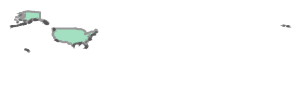

In [52]:
df.iloc[0,3]

In [59]:
#type(exploded.iloc[0,3])
#type(exploded.iloc[0,3])
#type(exploded.geom_type())

type(exploded.iloc[0].geometry)

shapely.geometry.polygon.Polygon

In [63]:
df.iloc[0].geometry.bounds
# returns: xmin,ymin,xmax,ymax 

(-178.19453125, 18.963916015625003, 179.77998046875, 71.407666015625)

In [64]:
# Get y min 
df.iloc[0].geometry.bounds[1]

18.963916015625003

In [102]:
 # Create function that receives 1 row of geodf and returns min-y coordinate
def min_y(row):
    y = row.geometry.bounds[1]
    return(y)


# TRY 2Use apply() to create new column of minimum y-coordinates of each polygon
df['min_y'] = df.apply(func=min_y, axis=1)

<Axes: >

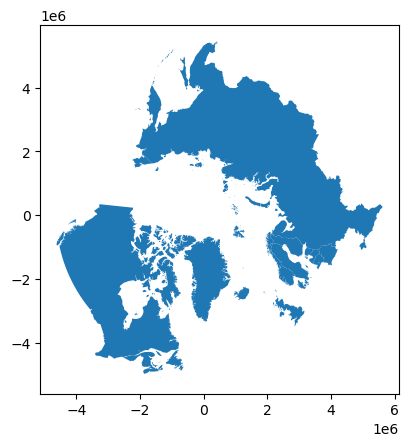

In [101]:
# FILTER AND UPDATE CRS AND REPRODUCE MAP 

artcic_countries = df[df['min_y']>= 40]
artcic_countries = artcic_countries.to_crs('epsg:3413')
artcic_countries.plot()